# Introduction

The goal of this notebook is to understand how multiple state schemas can be used in a single Graph (and how to change pass the state between them).

# Import

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

c:\Users\ssrim\anaconda3\envs\lc-academy-env\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


# Private State

This is a concept for when intermediate nodes require the exchanging of certain information but this is not relevant for the overall graph input/output. There may be a case where certain information is not meant to be seen by a user.

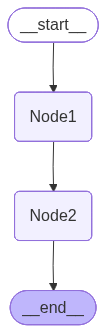

In [2]:
class OverallState(TypedDict):
    name: str
    middle_name: str
    score: int

class PrivateState(TypedDict):
    name: str
    last_name: str
    score: int

def node1(state: OverallState) -> PrivateState:
    print("Node 1 received state:", state)
    return {"score": state["score"] + 10}

def node2(state: PrivateState) -> OverallState:
    print("Node 2 received state:", state)
    return {"score": state["score"] * 2}

builder = StateGraph(OverallState)
builder.add_node("Node1", node1)
builder.add_node("Node2", node2)
builder.add_edge(START, "Node1")
builder.add_edge("Node1", "Node2")
builder.add_edge("Node2", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [3]:
graph.invoke({"name": "Billy", "middle_name": "Bob", "score": 5})

Node 1 received state: {'name': 'Billy', 'middle_name': 'Bob', 'score': 5}
Node 2 received state: {'name': 'Billy', 'score': 15}


{'name': 'Billy', 'middle_name': 'Bob', 'score': 30}

Note:
1. Even though the "name" key is not being explicitly passed between OverallState and PrivateState objects in Node1, it is still copied over as they have a common parameter ("name")
2. 'middle_name' is not passed from OverallState to PrivateState, however, it is still present in the output
3. 'last_name' is not in the output as it is not present in the OverallState schema

This could also be used to ensure that a particular node does not change anything it is not meant to be changing - by creating a state that has only the parameted that particular node should be having access to

# Input/Output Schema

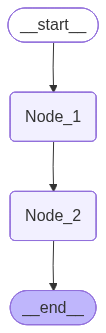

In [25]:
class OverallState(TypedDict):
    first_name: str
    last_name: str
    score: int
    full_name: str
    final_score: int

class InputSchema(TypedDict):
    first_name: str
    last_name: str
    score: int

class OutputSchema(TypedDict):
    full_name: str
    final_score: int

def node1(state: InputSchema) -> OverallState:
    print("Node 1 received state:", state)
    return {"full_name": state["first_name"] +" "+ state["last_name"], "final_score": state["score"]/100}

def node2(state: OverallState) -> OutputSchema:
    print("Node 2 received state:", state)
    return state

builder = StateGraph(InputSchema, input_schema=InputSchema, output_schema=OutputSchema)
builder.add_node("Node_1", node1)
builder.add_node("Node_2", node2)
builder.add_edge(START, "Node_1")
builder.add_edge("Node_1", "Node_2")
builder.add_edge("Node_2", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
graph.invoke({"first_name": "First", "last_name": "Last", "score": 35})

Node 1 received state: {'first_name': 'First', 'last_name': 'Last', 'score': 35}
Node 2 received state: {'first_name': 'First', 'last_name': 'Last', 'score': 35, 'full_name': 'First Last', 'final_score': 0.35}


{'full_name': 'First Last', 'final_score': 0.35}

In [16]:
graph.invoke({"first_name": "First", "last_name": "Last", "score": 35})

Node 1 received state: {'first_name': 'First', 'last_name': 'Last', 'score': 35}
Node 2 received state: {'full_name': 'First Last', 'final_score': 0.35}


{'first_name': 'First', 'last_name': 'Last', 'score': 35}

# Private State